# Q10 — Business Cost-Impact Modeling
Validates `src/xai/cost_impact.py`.

Answers: **What is the financial cost of under- or over-ordering based on this forecast?**

## 1) Imports and Paths

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import sys

sys.path.insert(0, str(Path('..').resolve() / 'src'))

from xai.cost_impact import (
    compute_stockout_cost,
    compute_overstock_cost,
    simulate_cost_distribution,
    optimal_order_quantity,
    generate_cost_impact_text,
)
from xai.uncertainty import compute_sku_residual_std, compute_prediction_interval

ROOT       = Path('..').resolve()
DATA_DIR   = ROOT / 'data' / 'processed' / 'LGBM_XGB_7_V3'
MODEL_PATH = ROOT / 'artifacts' / 'models' / 'tuned_lgbm_7_v3.joblib'

print('MODEL_PATH:', MODEL_PATH)

MODEL_PATH: C:\Users\amrok\Desktop\Thesis\Project_XAI\xai-retail-replenishment\artifacts\models\tuned_lgbm_7_v3.joblib


## 2) Load Model and Data

In [2]:
model    = joblib.load(MODEL_PATH)
train_df = pd.read_csv(DATA_DIR / 'train.csv')
test_df  = pd.read_csv(DATA_DIR / 'test.csv')

TARGET    = 'aggregated_sales_7'
DROP_COLS = [TARGET, 'date', 'item_id']
feature_cols = [c for c in train_df.columns if c not in DROP_COLS]

X_train = train_df[feature_cols].copy()
y_train = train_df[TARGET].copy()
X_test  = test_df[feature_cols].copy()

train_preds = model.predict(X_train)
test_preds  = model.predict(X_test)

# Compute per-SKU residual std for intervals
sku_std    = compute_sku_residual_std(y_train, train_preds, train_df['item_id'])
global_std = float(sku_std.mean())

# Pick a mid-selling SKU
sku_means  = test_df.groupby('item_id')[TARGET].mean()
target_sku = sku_means[(sku_means > 5) & (sku_means < 30)].index[0]
sku_rows   = test_df[test_df['item_id'] == target_sku]
sku_pred   = float(test_preds[test_df['item_id'] == target_sku][0])
sku_std_val= float(sku_std.get(target_sku, global_std))

interval   = compute_prediction_interval(sku_pred, sku_std_val)

print(f'SKU:  {target_sku}')
print(f'q10:  {interval["q10"]}  |  q50: {interval["q50"]}  |  q90: {interval["q90"]}')
print(f'Interval width: {interval["width"]}')

c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\e

[LightGBM] [Warning] feature_fraction is set=0.6865867534078534, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6865867534078534
[LightGBM] [Warning] bagging_fraction is set=0.6539685665916231, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6539685665916231
[LightGBM] [Warning] feature_fraction is set=0.6865867534078534, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6865867534078534
[LightGBM] [Warning] bagging_fraction is set=0.6539685665916231, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6539685665916231
SKU:  FOODS_1_001
q10:  1.1  |  q50: 4.54  |  q90: 7.99
Interval width: 6.89


c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


## 3) Simple Cost Primitives

In [3]:
# Business cost assumptions
UNIT_MARGIN  = 3.50   # $3.50 margin per unit (lost if stockout)
HOLDING_COST = 0.80   # $0.80 to hold one excess unit for 7 days

q50 = interval['q50']

# What if we order exactly q50?
so_cost = compute_stockout_cost(q50 * 1.2, q50, UNIT_MARGIN)    # demand 20% above forecast
os_cost = compute_overstock_cost(q50 * 0.8, q50, HOLDING_COST)  # demand 20% below forecast

print(f'If demand is 20% ABOVE forecast → stockout cost:  ${so_cost:.2f}')
print(f'If demand is 20% BELOW forecast → overstock cost: ${os_cost:.2f}')

If demand is 20% ABOVE forecast → stockout cost:  $3.18
If demand is 20% BELOW forecast → overstock cost: $0.73


## 4) Optimal Order Quantity (Newsvendor)

In [4]:
opt = optimal_order_quantity(
    q10          = interval['q10'],
    q50          = interval['q50'],
    q90          = interval['q90'],
    unit_margin  = UNIT_MARGIN,
    holding_cost = HOLDING_COST,
)

print('Newsvendor Optimal Order:')
for k, v in opt.items():
    print(f'  {k:25s}: {v}')

Newsvendor Optimal Order:
  optimal_qty              : 9.06
  critical_ratio           : 0.814
  implied_service_level    : 81.4
  mu                       : 1.5129
  sigma                    : 0.7746


## 5) Monte Carlo Cost Simulation

In [5]:
sim_df = simulate_cost_distribution(
    q10          = interval['q10'],
    q50          = interval['q50'],
    q90          = interval['q90'],
    order_qty    = opt['optimal_qty'],
    unit_margin  = UNIT_MARGIN,
    holding_cost = HOLDING_COST,
    n_simulations= 10_000,
)

print(f'Simulation rows: {len(sim_df)}')
print(f'\nExpected costs at optimal order qty ({opt["optimal_qty"]:.1f} units):')
print(f'  Mean stockout cost:   ${sim_df["stockout_cost"].mean():.2f}')
print(f'  Mean overstock cost:  ${sim_df["overstock_cost"].mean():.2f}')
print(f'  Mean total cost:      ${sim_df["total_cost"].mean():.2f}')
print(f'  P95 total cost:       ${sim_df["total_cost"].quantile(0.95):.2f}')
print(f'\nDemand distribution summary:')
print(sim_df['demand'].describe().round(2))

Simulation rows: 10000

Expected costs at optimal order qty (9.1 units):
  Mean stockout cost:   $3.85
  Mean overstock cost:  $3.24
  Mean total cost:      $7.10
  P95 total cost:       $25.01

Demand distribution summary:
count    10000.00
mean         6.11
std          5.61
min          0.15
25%          2.69
50%          4.49
75%          7.51
max        102.64
Name: demand, dtype: float64


## 6) Visualize Cost Distribution

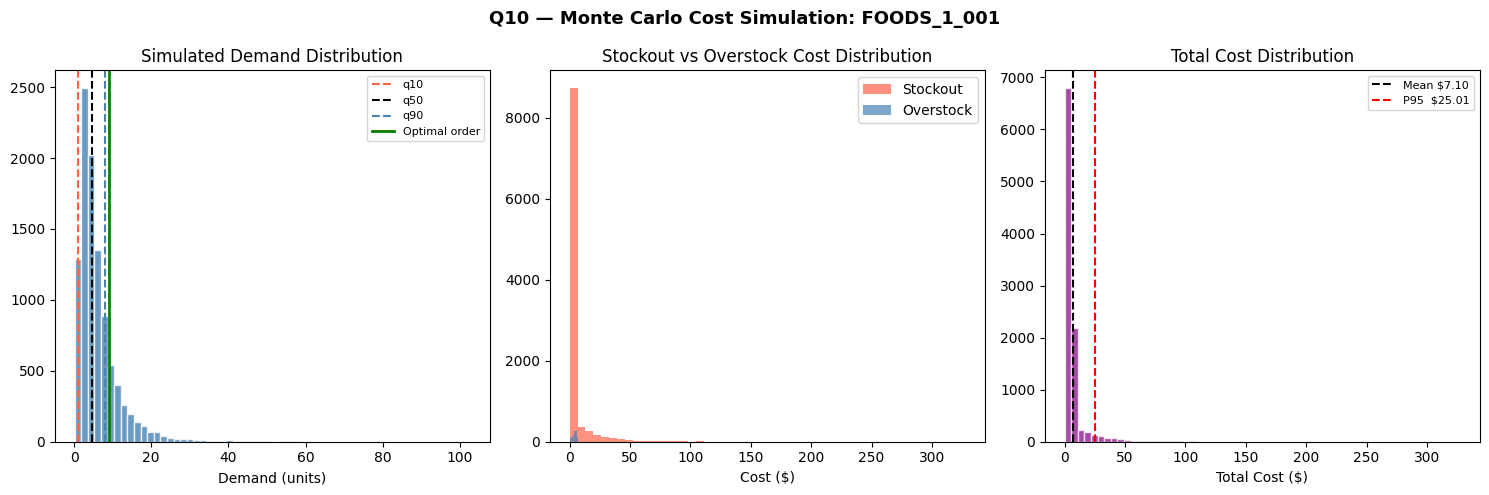

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].hist(sim_df['demand'], bins=60, color='steelblue', alpha=0.8, edgecolor='white')
axes[0].axvline(interval['q10'], color='tomato',    linestyle='--', label='q10')
axes[0].axvline(interval['q50'], color='black',     linestyle='--', label='q50')
axes[0].axvline(interval['q90'], color='steelblue', linestyle='--', label='q90')
axes[0].axvline(opt['optimal_qty'], color='green',  linestyle='-',  linewidth=2, label='Optimal order')
axes[0].set_title('Simulated Demand Distribution')
axes[0].set_xlabel('Demand (units)')
axes[0].legend(fontsize=8)

axes[1].hist(sim_df['stockout_cost'],  bins=50, color='tomato',    alpha=0.7, label='Stockout')
axes[1].hist(sim_df['overstock_cost'], bins=50, color='steelblue', alpha=0.7, label='Overstock')
axes[1].set_title('Stockout vs Overstock Cost Distribution')
axes[1].set_xlabel('Cost ($)')
axes[1].legend()

axes[2].hist(sim_df['total_cost'], bins=60, color='purple', alpha=0.7, edgecolor='white')
axes[2].axvline(sim_df['total_cost'].mean(),          color='black', linestyle='--', label=f'Mean ${sim_df["total_cost"].mean():.2f}')
axes[2].axvline(sim_df['total_cost'].quantile(0.95),  color='red',   linestyle='--', label=f'P95  ${sim_df["total_cost"].quantile(0.95):.2f}')
axes[2].set_title('Total Cost Distribution')
axes[2].set_xlabel('Total Cost ($)')
axes[2].legend(fontsize=8)

plt.suptitle(f'Q10 — Monte Carlo Cost Simulation: {target_sku}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7) Cost vs Order Quantity Curve

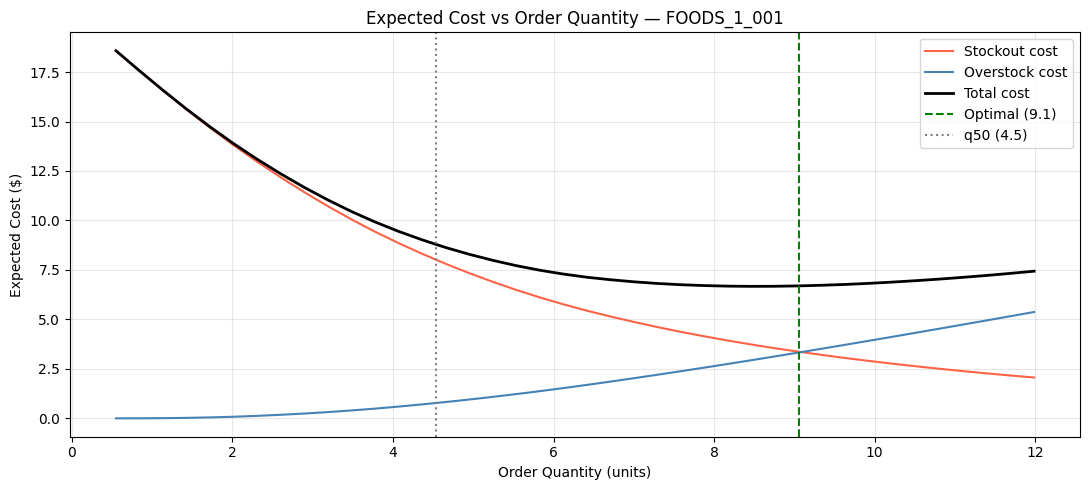

In [7]:
order_range = np.linspace(interval['q10'] * 0.5, interval['q90'] * 1.5, 40)
cost_rows   = []

for oq in order_range:
    s = simulate_cost_distribution(
        interval['q10'], interval['q50'], interval['q90'],
        oq, UNIT_MARGIN, HOLDING_COST, n_simulations=2000, seed=42
    )
    cost_rows.append({
        'order_qty':     oq,
        'mean_stockout': s['stockout_cost'].mean(),
        'mean_overstock':s['overstock_cost'].mean(),
        'mean_total':    s['total_cost'].mean(),
    })

cost_curve = pd.DataFrame(cost_rows)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(cost_curve['order_qty'], cost_curve['mean_stockout'],  label='Stockout cost',  color='tomato')
ax.plot(cost_curve['order_qty'], cost_curve['mean_overstock'], label='Overstock cost', color='steelblue')
ax.plot(cost_curve['order_qty'], cost_curve['mean_total'],     label='Total cost',     color='black', linewidth=2)
ax.axvline(opt['optimal_qty'], color='green', linestyle='--', linewidth=1.5, label=f'Optimal ({opt["optimal_qty"]:.1f})')
ax.axvline(interval['q50'],    color='gray',  linestyle=':',  linewidth=1.5, label=f'q50 ({interval["q50"]:.1f})')
ax.set_xlabel('Order Quantity (units)')
ax.set_ylabel('Expected Cost ($)')
ax.set_title(f'Expected Cost vs Order Quantity — {target_sku}')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8) NLG Cost-Impact Summary

In [8]:
text = generate_cost_impact_text(
    sku_id                  = target_sku,
    q50                     = interval['q50'],
    optimal_qty             = opt['optimal_qty'],
    expected_stockout_cost  = sim_df['stockout_cost'].mean(),
    expected_overstock_cost = sim_df['overstock_cost'].mean(),
    unit_margin             = UNIT_MARGIN,
    holding_cost            = HOLDING_COST,
    critical_ratio          = opt['critical_ratio'],
)
print(text)

=== Cost-Impact Analysis: FOODS_1_001 ===
Point forecast (q50):       4.5 units
Optimal order quantity:     9.1 units  (above forecast by 4.5 units)

Cost parameters:
  Unit margin (stockout cost):  $3.50/unit
  Holding cost (overstock):     $0.80/unit
  Critical ratio:               81.40%

Expected costs at optimal order quantity:
  Stockout cost:   $3.85
  Overstock cost:  $3.24
  Total:           $7.10

Dominant risk: STOCKOUT
The stockout risk outweighs overstock cost — the high unit margin ($3.50) means lost sales are more expensive than holding excess stock. Consider ordering above the point forecast.
